# Amplitude Modulation in AM Radio

This notebook is a tutorial on how **amplitude modulation (AM)** works in broadcast radio, with a more EE-oriented treatment than a purely conceptual introduction.

We will cover:

1. Historical context for AM broadcasting
2. The message signal and the carrier
3. The standard AM signal model
4. Modulation index and envelope behavior
5. Frequency-domain interpretation and sidebands
6. Bandwidth and power relations
7. Envelope detection and RC time constants
8. Comparison with DSB-SC and SSB


## 1. Historical context

AM was the first widely adopted technique for carrying audio over long distances by radio. In the early 20th century, radio engineers needed a practical way to place speech and music onto a much higher-frequency electromagnetic wave that could be efficiently radiated by an antenna.

A few milestones:

- Early radio systems first transmitted unmodulated carrier-like bursts for telegraphy.
- As vacuum-tube transmitters and detectors improved, continuous-wave transmission became practical.
- Amplitude modulation became a straightforward method for broadcasting voice and music because it was easy to generate and easy to demodulate.
- By the 1920s, AM broadcasting had become the dominant public radio format in many countries.
- Even though FM later offered better noise performance, AM remained important because of its simpler receivers, lower occupied audio bandwidth, and long-distance nighttime propagation in the medium-wave band.

From an engineering perspective, AM is historically important because it cleanly illustrates the central idea of modulation: use a low-frequency information signal to control some parameter of a high-frequency carrier.


## 2. Core idea

An AM transmitter sends information by changing the **amplitude** of a high-frequency carrier wave.

A standard mathematical model is:

$$
s(t) = A_c \left(1 + \mu x(t)\right)\cos(2\pi f_c t)
$$

where:

- $A_c$ is the carrier amplitude
- $f_c$ is the carrier frequency
- $x(t)$ is the normalized message signal, typically with $|x(t)| \le 1$
- $\mu$ is the modulation index

If $0 \le \mu \le 1$ and the message is normalized, then the envelope remains nonnegative and a simple envelope detector can recover the audio without severe distortion.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Simulation parameters
fs = 200_000
duration = 0.004
t = np.arange(0, duration, 1 / fs)

# Message and carrier
fm = 1_000
fc = 20_000
Ac = 1.0
mu = 0.7

message = np.cos(2 * np.pi * fm * t)
carrier = Ac * np.cos(2 * np.pi * fc * t)
am_signal = Ac * (1 + mu * message) * np.cos(2 * np.pi * fc * t)
upper_envelope = Ac * (1 + mu * message)
lower_envelope = -upper_envelope


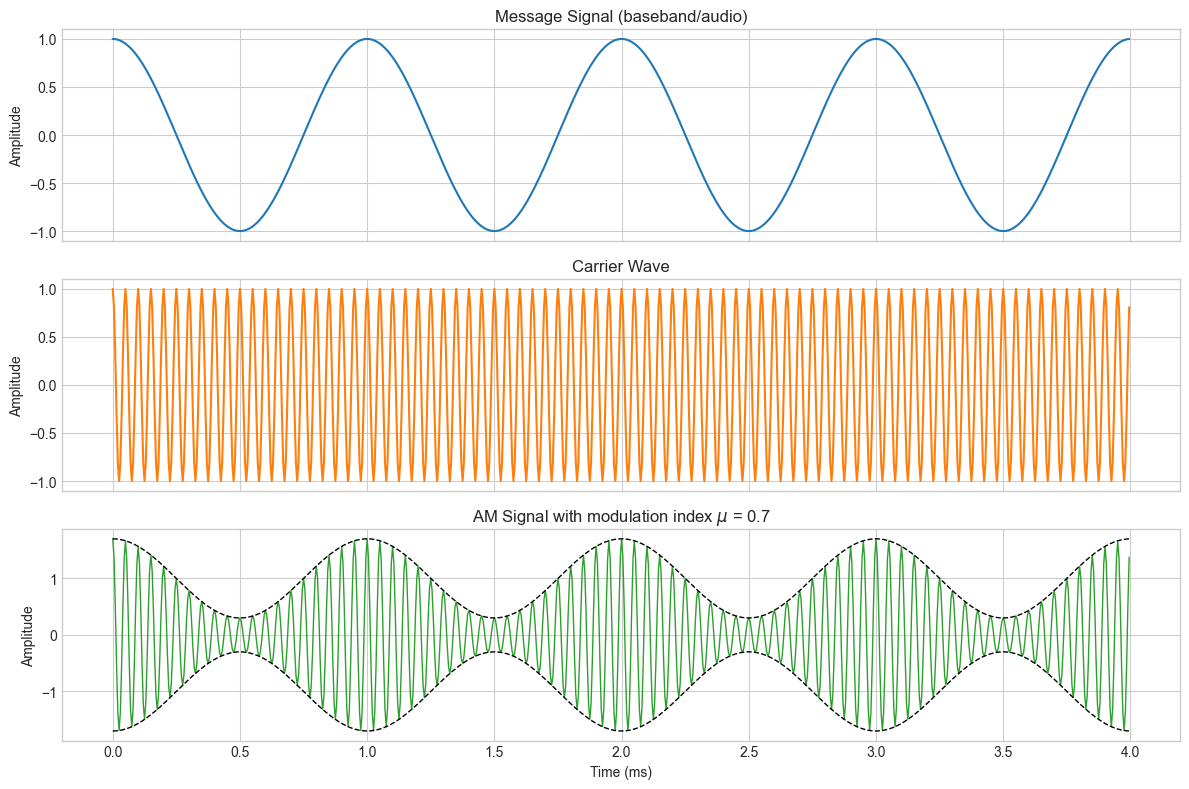

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t * 1000, message, color='tab:blue')
axes[0].set_title('Message Signal (baseband/audio)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t * 1000, carrier, color='tab:orange')
axes[1].set_title('Carrier Wave')
axes[1].set_ylabel('Amplitude')

axes[2].plot(t * 1000, am_signal, color='tab:green', linewidth=1)
axes[2].plot(t * 1000, upper_envelope, '--', color='black', linewidth=1)
axes[2].plot(t * 1000, lower_envelope, '--', color='black', linewidth=1)
axes[2].set_title(f'AM Signal with modulation index ' + r'$\mu$' + f' = {mu}')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()


## 3. Derivation for a single-tone message

Let the message be a single sinusoid:

$$
x(t) = \cos(2\pi f_m t)
$$

Then

$$
s(t) = A_c\left(1 + \mu\cos(2\pi f_m t)\right)\cos(2\pi f_c t)
$$

Expanding gives

$$
s(t) = A_c\cos(2\pi f_c t) + A_c\mu\cos(2\pi f_m t)\cos(2\pi f_c t)
$$

Now apply the product-to-sum identity

$$
\cos \alpha \cos \beta = \frac{1}{2}\left[\cos(\alpha+\beta) + \cos(\alpha-\beta)\right]
$$

to obtain

$$
s(t) = A_c\cos(2\pi f_c t) + \frac{A_c\mu}{2}\cos(2\pi(f_c+f_m)t) + \frac{A_c\mu}{2}\cos(2\pi(f_c-f_m)t)
$$

This is the standard decomposition of ordinary AM into:

- a carrier at $f_c$
- an upper sideband at $f_c + f_m$
- a lower sideband at $f_c - f_m$


## 4. What the modulation index changes

The modulation index $\mu$ controls how strongly the carrier amplitude responds to the message.

- `mu = 0`: no modulation, only the carrier is transmitted
- `0 < mu < 1`: under-modulated or normally modulated AM
- `mu = 1`: 100% modulation
- `mu > 1`: overmodulation, where the envelope crosses through zero and simple envelope detection breaks down

For a normalized single-tone message, the envelope is

$$
A_{env}(t) = A_c(1 + \mu \cos(2\pi f_m t))
$$

Its minimum value is $A_c(1-\mu)$, so to avoid envelope inversion we require $\mu \le 1$.


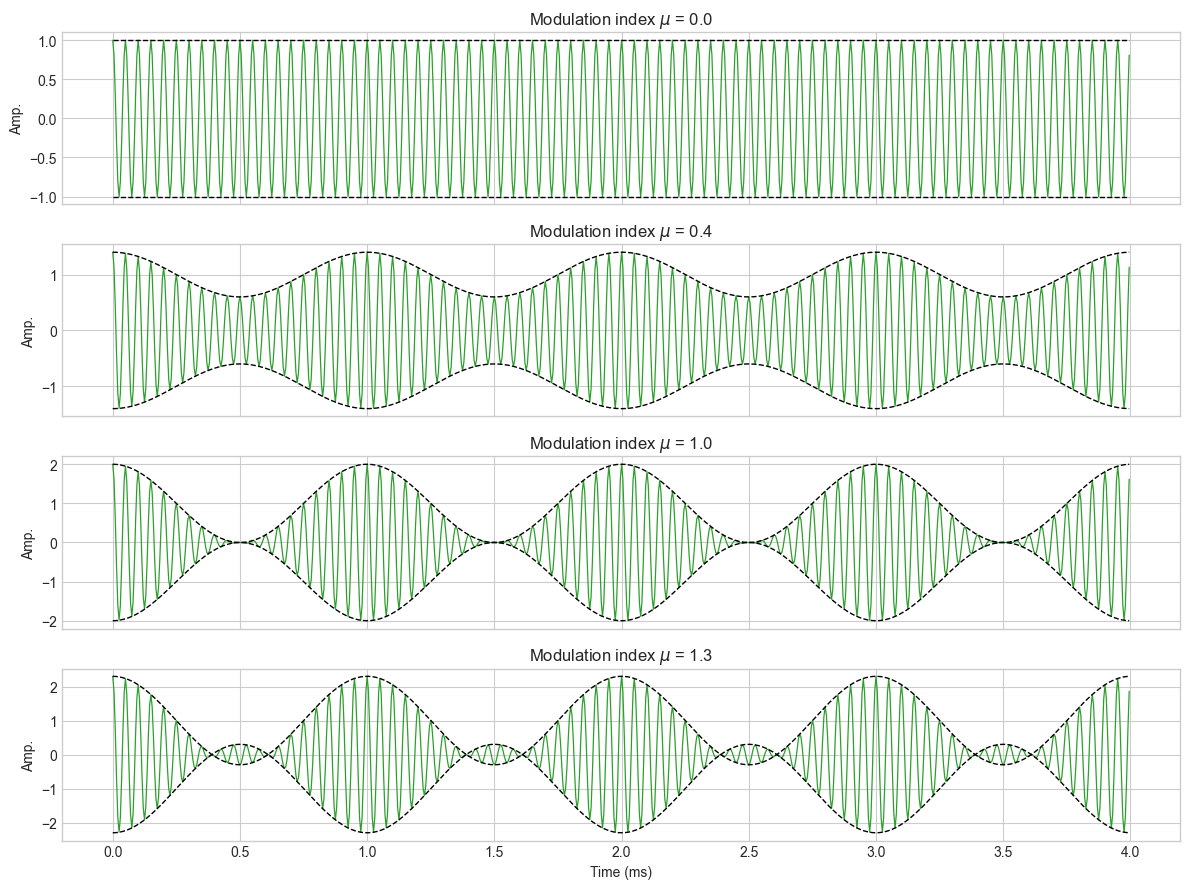

In [3]:
modulation_indices = [0.0, 0.4, 1.0, 1.3]
fig, axes = plt.subplots(len(modulation_indices), 1, figsize=(12, 9), sharex=True)

for ax, mi in zip(axes, modulation_indices):
    s = Ac * (1 + mi * message) * np.cos(2 * np.pi * fc * t)
    env = Ac * (1 + mi * message)
    ax.plot(t * 1000, s, color='tab:green', linewidth=0.9)
    ax.plot(t * 1000, env, '--', color='black', linewidth=1)
    ax.plot(t * 1000, -env, '--', color='black', linewidth=1)
    ax.set_title(f'Modulation index ' + r'$\mu$' + f' = {mi}')
    ax.set_ylabel('Amp.')

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()


## 5. Fourier-transform view

The single-tone expansion is useful, but in communications theory it is more common to reason in terms of spectra.

Write the AM signal as

$$
s(t) = A_c\cos(2\pi f_c t) + A_c\mu x(t)\cos(2\pi f_c t)
$$

If $X(f)$ is the Fourier transform of $x(t)$, then multiplying by a cosine shifts the baseband spectrum to positive and negative carrier frequencies:

$$
\mathcal{F}\{x(t)\cos(2\pi f_c t)\} = \frac{1}{2}\left[X(f-f_c) + X(f+f_c)\right]
$$

So the AM spectrum is

$$
S(f) = \frac{A_c}{2}\left[\delta(f-f_c) + \delta(f+f_c)\right] + \frac{A_c\mu}{2}\left[X(f-f_c) + X(f+f_c)\right]
$$

This expression says three things at once:

- the carrier contributes impulses at $\pm f_c$
- the message spectrum is translated to sit around $+f_c$
- an equal mirrored copy appears around $-f_c$

For a real passband signal, that conjugate symmetry is exactly what we expect.


## 6. Spectrum and sidebands

In real broadcast AM, the message is not a single sinusoid but a band of audio frequencies. If the message occupies frequencies from 0 to $B$, then the modulated signal produces translated copies of that spectrum centered around $\pm f_c$.

That means the transmitted AM spectrum occupies:

- a lower sideband from $f_c - B$ to $f_c$
- an upper sideband from $f_c$ to $f_c + B$

So the total transmission bandwidth is:

$$
BW_{AM} = 2B
$$

This is one reason standard AM is spectrally less efficient than single-sideband transmission, which suppresses one sideband and usually the carrier as well.


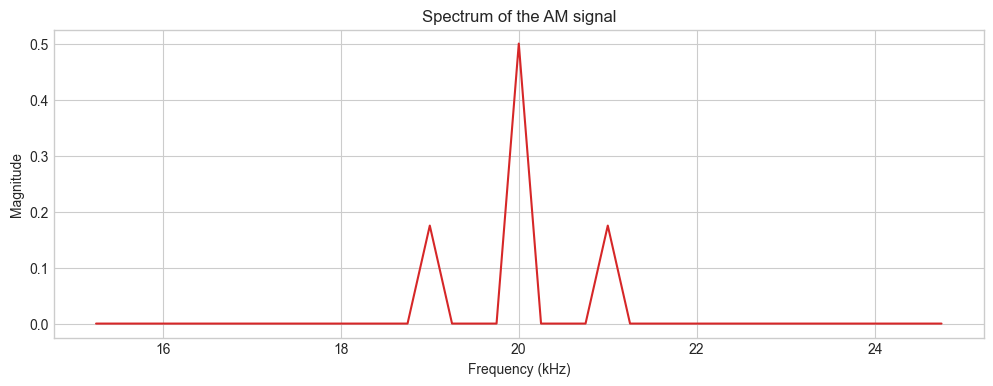

Expected lower sideband: 19.0 kHz
Expected carrier:         20.0 kHz
Expected upper sideband: 21.0 kHz


In [4]:
def single_sided_spectrum(signal, fs):
    n = len(signal)
    spectrum = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    mag = np.abs(spectrum) / n
    return freqs, mag

freqs, mag = single_sided_spectrum(am_signal, fs)
mask = (freqs > fc - 5 * fm) & (freqs < fc + 5 * fm)

plt.figure(figsize=(12, 4))
plt.plot(freqs[mask] / 1000, mag[mask], color='tab:red')
plt.title('Spectrum of the AM signal')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnitude')
plt.show()

print(f'Expected lower sideband: {(fc - fm) / 1000:.1f} kHz')
print(f'Expected carrier:         {fc / 1000:.1f} kHz')
print(f'Expected upper sideband: {(fc + fm) / 1000:.1f} kHz')


## 7. Power in the carrier and sidebands

For a sinusoidal AM signal across a resistive load $R$,

$$
s(t) = A_c\cos(2\pi f_c t) + \frac{A_c\mu}{2}\cos(2\pi(f_c+f_m)t) + \frac{A_c\mu}{2}\cos(2\pi(f_c-f_m)t)
$$

the average power of a cosine with peak amplitude $A$ across resistance $R$ is

$$
P = \frac{A^2}{2R}
$$

So:

- Carrier power:

$$
P_c = \frac{A_c^2}{2R}
$$

- Power in each sideband:

$$
P_{USB} = P_{LSB} = \frac{(A_c\mu/2)^2}{2R} = \frac{A_c^2\mu^2}{8R}
$$

- Total sideband power:

$$
P_{SB} = \frac{A_c^2\mu^2}{4R} = P_c\frac{\mu^2}{2}
$$

- Total transmitted power:

$$
P_T = P_c\left(1 + \frac{\mu^2}{2}\right)
$$

This shows a well-known drawback of ordinary AM: most transmitted power can sit in the carrier, which carries no independent message information.


In [5]:
R = 50
Pc = Ac**2 / (2 * R)
Pusb = (Ac * mu / 2)**2 / (2 * R)
Plsb = Pusb
Psb = Pusb + Plsb
Pt = Pc + Psb
efficiency = Psb / Pt

print(f'Carrier power Pc         = {Pc:.6f} W')
print(f'Upper sideband power     = {Pusb:.6f} W')
print(f'Lower sideband power     = {Plsb:.6f} W')
print(f'Total sideband power     = {Psb:.6f} W')
print(f'Total transmitted power  = {Pt:.6f} W')
print(f'Modulation efficiency    = {100 * efficiency:.2f}%')


Carrier power Pc         = 0.010000 W
Upper sideband power     = 0.001225 W
Lower sideband power     = 0.001225 W
Total sideband power     = 0.002450 W
Total transmitted power  = 0.012450 W
Modulation efficiency    = 19.68%


For standard AM with a sinusoidal modulating tone, the efficiency is

$$
\eta = \frac{P_{SB}}{P_T} = \frac{\mu^2/2}{1 + \mu^2/2}
$$

At 100% modulation ($\mu = 1$), this becomes

$$
\eta = \frac{1/2}{1 + 1/2} = \frac{1}{3}
$$

So even at full modulation, only one-third of the transmitted power is in the sidebands that actually convey the audio content.


## 8. Envelope detection and RC time constants

A basic AM receiver can recover the audio by tracking the signal envelope. A simplified computational model is:

1. Rectify the signal by taking its absolute value
2. Low-pass filter or smooth it
3. Remove the DC offset

A real AM receiver often uses a diode-capacitor envelope detector followed by audio filtering and amplification.

The RC time constant has to satisfy two competing goals:

- It should be **large compared with the carrier period** so the capacitor does not discharge much between RF cycles.
- It should be **small compared with the modulation period** so the output can follow the envelope.

In engineering shorthand, this is often written as:

$$
\frac{1}{2\pi f_c} \ll RC \ll \frac{1}{2\pi B}
$$

where $B$ is the highest audio frequency that must be tracked.

For a single-tone modulating signal, a more specific distortion-avoidance condition is often written as:

$$
RC \ll \frac{1}{\omega_m \mu}
$$

at least as a design guideline, because heavy modulation and high audio frequency both demand faster envelope tracking.


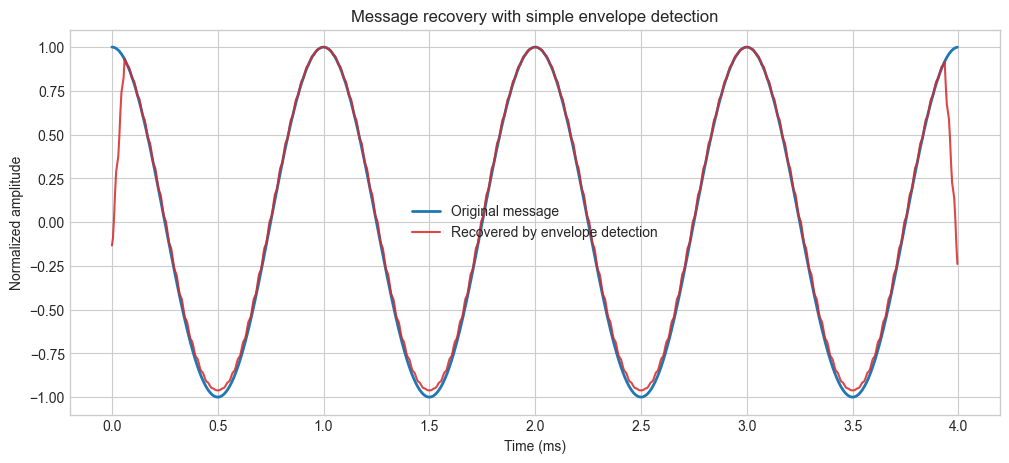

In [6]:
rectified = np.abs(am_signal)

# A moving average acts as a simple low-pass filter for the rectified waveform.
window = int(fs / (8 * fm))
window = max(window, 3)
kernel = np.ones(window) / window
detected = np.convolve(rectified, kernel, mode='same')

detected_audio = detected - np.mean(detected)
detected_audio /= np.max(np.abs(detected_audio))

plt.figure(figsize=(12, 5))
plt.plot(t * 1000, message, label='Original message', color='tab:blue', linewidth=2)
plt.plot(t * 1000, detected_audio, label='Recovered by envelope detection', color='tab:red', alpha=0.85)
plt.title('Message recovery with simple envelope detection')
plt.xlabel('Time (ms)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.show()


In [ ]:
carrier_time_constant = 1 / (2 * np.pi * fc)
envelope_time_constant = 1 / (2 * np.pi * fm)
suggested_rc = np.sqrt(carrier_time_constant * envelope_time_constant)

print(f'1/(2*pi*fc) = {carrier_time_constant:.6e} s')
print(f'1/(2*pi*fm) = {envelope_time_constant:.6e} s')
print(f'One geometric-mean RC choice = {suggested_rc:.6e} s')


## 9. Comparing AM, DSB-SC, and SSB

Three closely related amplitude-modulation schemes are:

### Ordinary AM

$$
s_{AM}(t) = A_c(1 + \mu x(t))\cos(2\pi f_c t)
$$

- Carrier present
- Both sidebands present
- Bandwidth: $2B$
- Simple envelope detection possible

### Double-sideband suppressed-carrier (DSB-SC)

$$
s_{DSB-SC}(t) = A_c x(t)\cos(2\pi f_c t)
$$

- Carrier suppressed
- Both sidebands present
- Bandwidth: $2B$
- More power-efficient than ordinary AM
- Requires coherent demodulation, not simple envelope detection

### Single-sideband (SSB)

One common way to think of SSB is that we keep only one translated copy of the baseband spectrum.

- Carrier usually reduced or suppressed
- Only one sideband transmitted
- Bandwidth: $B$
- Highest spectral efficiency of the three
- Receiver design is more demanding because it needs accurate frequency re-insertion or product detection


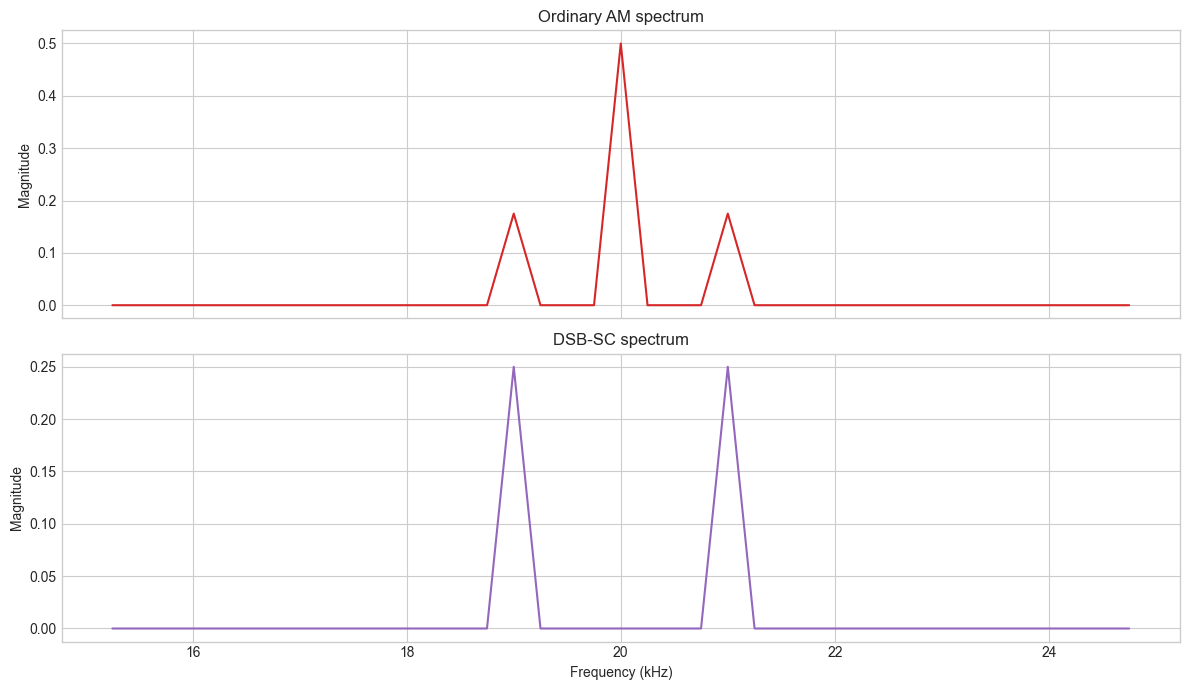

In [7]:
dsb_sc_signal = Ac * message * np.cos(2 * np.pi * fc * t)

freqs_dsb, mag_dsb = single_sided_spectrum(dsb_sc_signal, fs)
mask_dsb = (freqs_dsb > fc - 5 * fm) & (freqs_dsb < fc + 5 * fm)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(freqs[mask] / 1000, mag[mask], color='tab:red')
axes[0].set_title('Ordinary AM spectrum')
axes[0].set_ylabel('Magnitude')

axes[1].plot(freqs_dsb[mask_dsb] / 1000, mag_dsb[mask_dsb], color='tab:purple')
axes[1].set_title('DSB-SC spectrum')
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Magnitude')

plt.tight_layout()
plt.show()


Notice that DSB-SC removes the large carrier line at $f_c$, leaving only the sidebands. That is why it improves power efficiency, even though its bandwidth is the same as ordinary AM.

SSB goes one step further by removing one of the sidebands too, cutting the required bandwidth in half.


## 10. Key takeaways

- AM places information in the **envelope** of a radio-frequency carrier.
- A single modulating tone produces a carrier plus two sidebands.
- In the Fourier domain, modulation shifts a baseband spectrum to sit around the carrier frequency.
- If the audio baseband extends to $B$, then standard AM requires bandwidth $2B$.
- Ordinary AM is easy to demodulate, but it is not power-efficient because the carrier consumes substantial power.
- DSB-SC improves power efficiency by suppressing the carrier.
- SSB improves bandwidth efficiency by transmitting only one sideband.

Possible extensions:

- Add coherent demodulation for DSB-SC
- Build an actual RC-envelope detector difference equation
- Use a Hilbert transform construction to synthesize SSB
- Replace the sinusoidal message with a sampled speech waveform
